Visualizations 

In [2]:
# import libraties 

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

In [3]:
#load new cleaned dataset 

df = pd.read_csv("../data/processed/nvidia_gpu_sales_cleaned.csv")

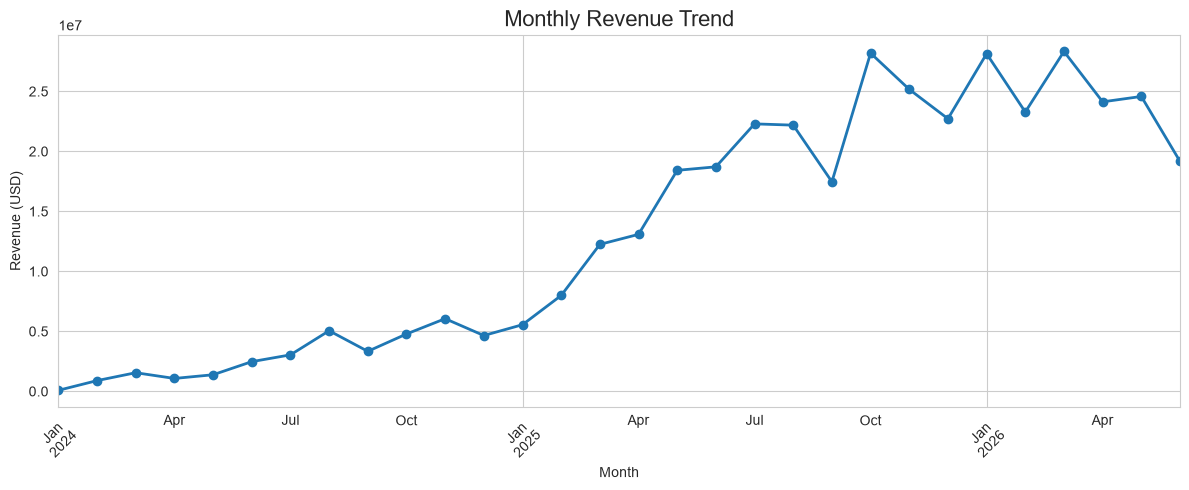

In [4]:
#Analyze GPU sales performance and revenue trends over time.

# Shows how NVIDIA revenue changes over time and helps identify:

# Growth periods
# Declining periods
# Seasonal sales patterns


df["sale_date"] = pd.to_datetime(df["sale_date"])

monthly_revenue = (
    df.groupby(df["sale_date"].dt.to_period("M"))["revenue_usd"]
    .sum()
)

plt.figure(figsize=(12,5))

monthly_revenue.plot(
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visualizations/monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



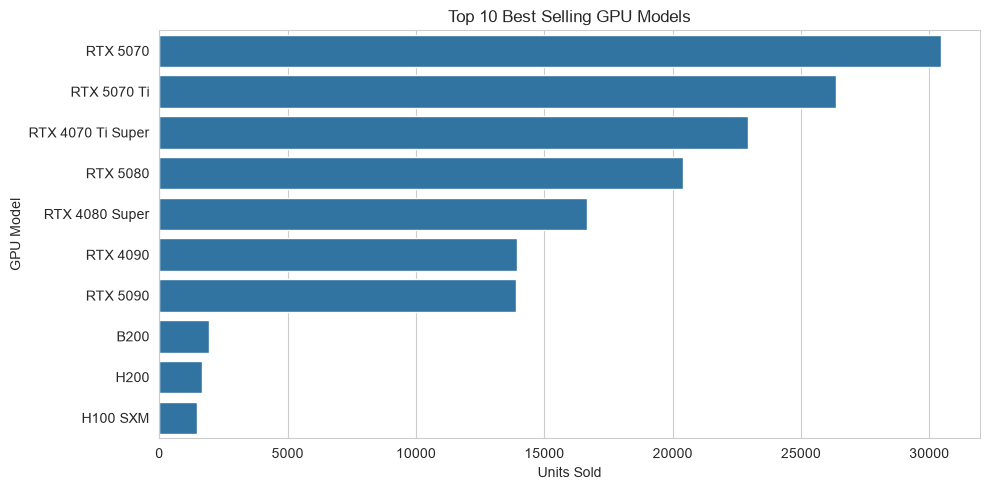

In [5]:
# Identify best-selling GPU models.

# Identifies:

# Most demanded GPUs
# Popular products
# Customer preferences


top_gpu_sales = (
    df.groupby("gpu_model")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


plt.figure(figsize=(10,5))

sns.barplot(
    x=top_gpu_sales.values,
    y=top_gpu_sales.index
)

plt.title("Top 10 Best Selling GPU Models")
plt.xlabel("Units Sold")
plt.ylabel("GPU Model")

plt.tight_layout()

plt.savefig(
    "../visualizations/Identify_best-selling_GPU_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()




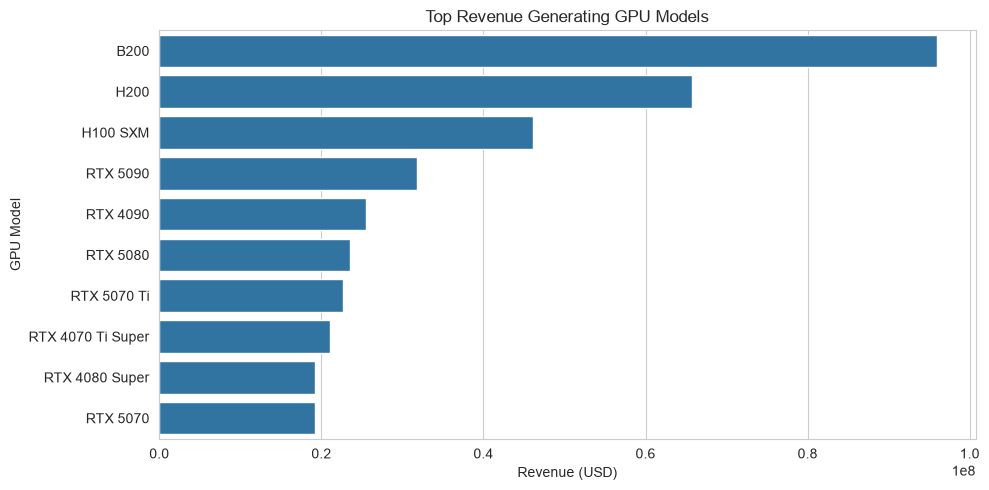

In [6]:
# Revenue by GPU Model

# A GPU may sell fewer units but generate more revenue due to premium pricing.


top_revenue_gpu = (
    df.groupby("gpu_model")["revenue_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


plt.figure(figsize=(10,5))

sns.barplot(
    x=top_revenue_gpu.values,
    y=top_revenue_gpu.index
)

plt.title("Top Revenue Generating GPU Models")
plt.xlabel("Revenue (USD)")
plt.ylabel("GPU Model")

plt.tight_layout()

plt.savefig(
    "../visualizations/Revenue_by_GPU_Model.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



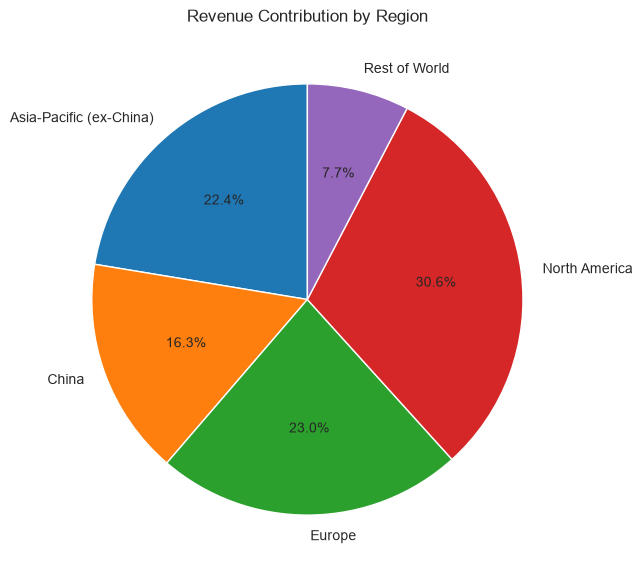

In [7]:
# Revenue Contribution by Region

# Shows which regions contribute most to NVIDIA revenue.

region_revenue = (
    df.groupby("region")["revenue_usd"]
    .sum()
)


plt.figure(figsize=(7,7))

plt.pie(
    region_revenue,
    labels=region_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Contribution by Region")

plt.savefig(
    "../visualizations/Revenue_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



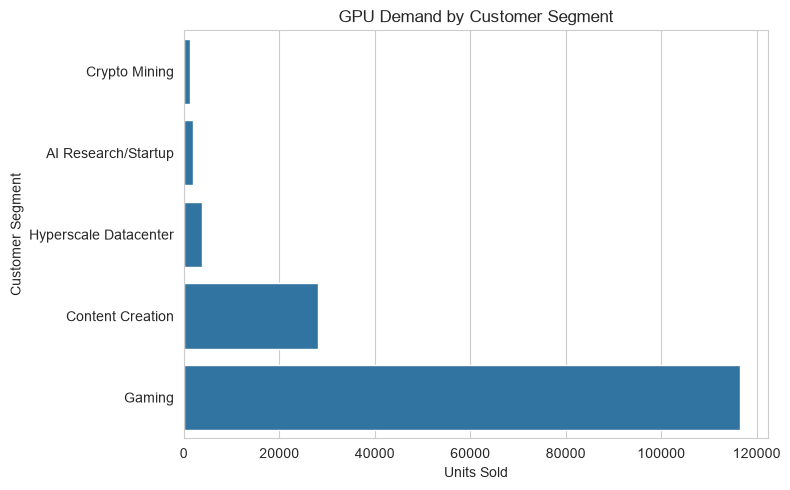

In [8]:
# Customer Purchasing Pattern

# Helps understand product demand:

# Gaming demand
# Enterprise demand
# Professional users


segment_sales = (
    df.groupby("customer_segment")["units_sold"]
    .sum()
    .sort_values()
)


plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.values,
    y=segment_sales.index
)

plt.title("GPU Demand by Customer Segment")

plt.xlabel("Units Sold")
plt.ylabel("Customer Segment")

plt.tight_layout()

plt.savefig(
    "../visualizations/Demand_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()





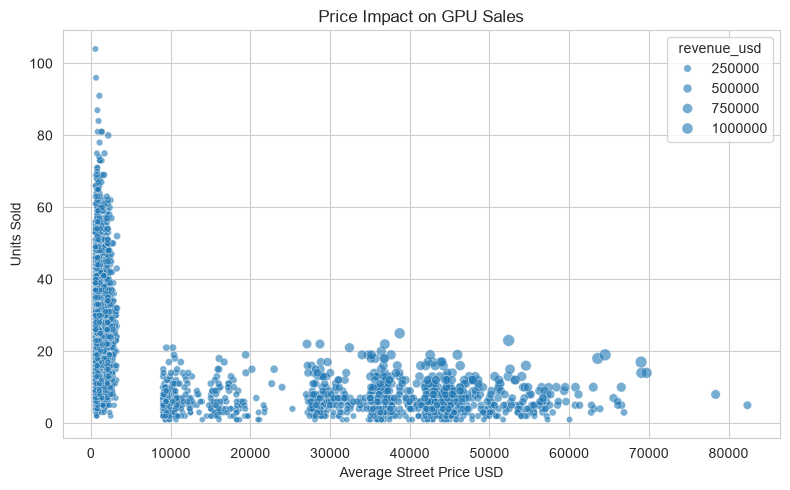

In [9]:
# Understand whether price affects product demand.

# Shows:

# Expensive GPUs selling less/more
# Relationship between price and demand


plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="avg_street_price_usd",
    y="units_sold",
    size="revenue_usd",
    alpha=0.6
)


plt.title("Price Impact on GPU Sales")
plt.xlabel("Average Street Price USD")
plt.ylabel("Units Sold")

plt.tight_layout()

plt.savefig(
    "../visualizations/Price_impact_on-sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



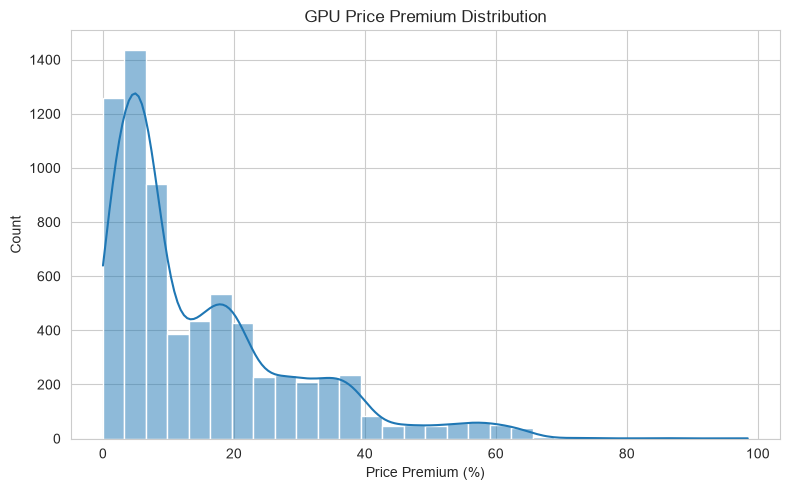

In [10]:
# Price Premium Analysis

# Shows how much customers pay above MSRP.


plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="price_premium_pct",
    bins=30,
    kde=True
)


plt.title("GPU Price Premium Distribution")
plt.xlabel("Price Premium (%)")

plt.tight_layout()

plt.savefig(
    "../visualizations/price_premium_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



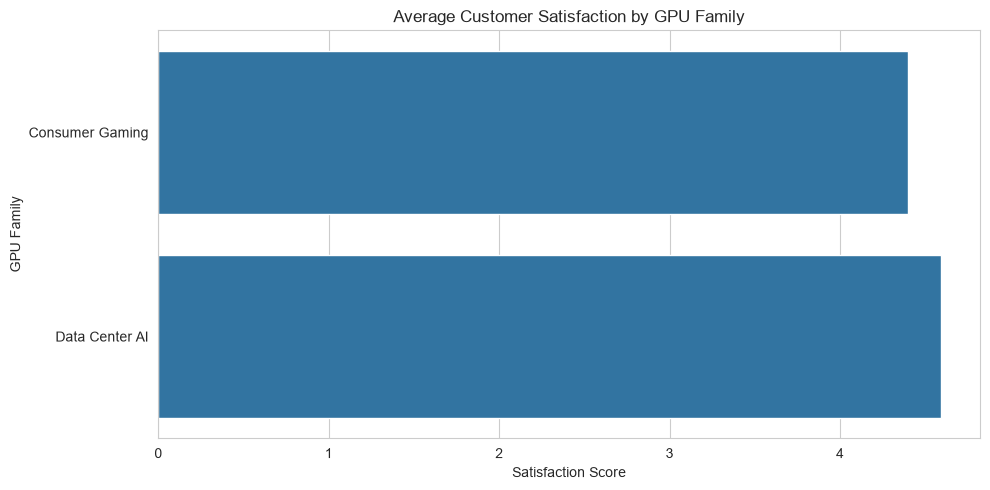

In [11]:
# Customer Satisfaction Analysis

# Identifies products with better customer experience.


satisfaction = (
    df.groupby("gpu_family")
    ["customer_satisfaction_score"]
    .mean()
    .sort_values()
)


plt.figure(figsize=(10,5))

sns.barplot(
    x=satisfaction.values,
    y=satisfaction.index
)


plt.title("Average Customer Satisfaction by GPU Family")

plt.xlabel("Satisfaction Score")
plt.ylabel("GPU Family")

plt.tight_layout()

plt.savefig(
    "../visualizations/Customer_satisfaction_by_GPU.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



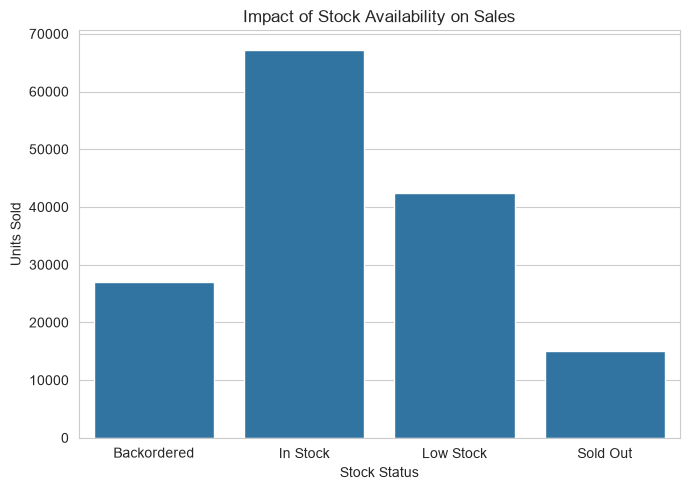

In [12]:
# Inventory Availability Impact

# Shows whether stock availability affects sales.


stock_sales = (
    df.groupby("stock_status")
    ["units_sold"]
    .sum()
)


plt.figure(figsize=(7,5))

sns.barplot(
    x=stock_sales.index,
    y=stock_sales.values
)


plt.title("Impact of Stock Availability on Sales")

plt.xlabel("Stock Status")
plt.ylabel("Units Sold")


plt.tight_layout()

plt.savefig(
    "../visualizations/Inventory_Availability_Impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



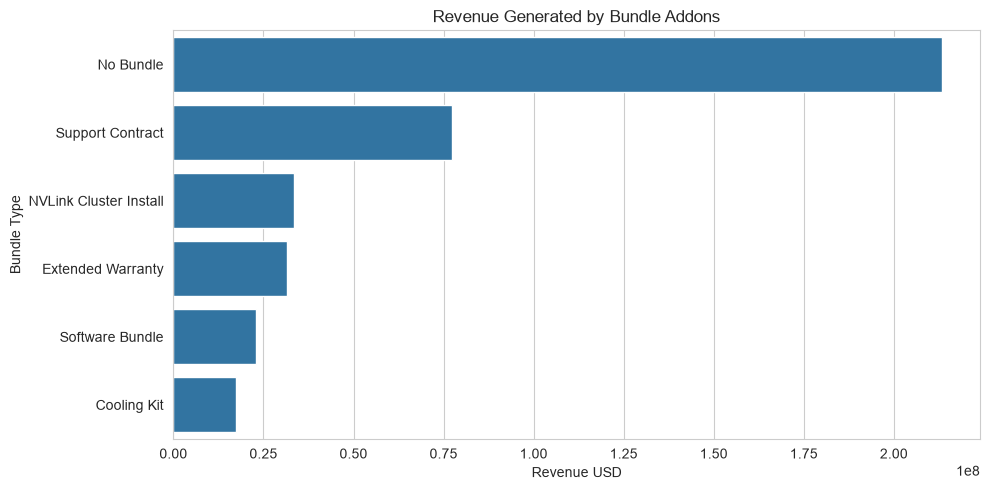

In [13]:
# Bundle Revenue Analysis

# Shows which bundles increase additional revenue.

bundle_revenue = (
    df.groupby("bundle_addon")
    ["revenue_usd"]
    .sum()
    .sort_values(ascending=False)
)


plt.figure(figsize=(10,5))

sns.barplot(
    x=bundle_revenue.values,
    y=bundle_revenue.index
)


plt.title("Revenue Generated by Bundle Addons")

plt.xlabel("Revenue USD")
plt.ylabel("Bundle Type")


plt.tight_layout()

plt.savefig(
    "../visualizations/Bundle-revenue_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

